In [3]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [4]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [12]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

from scripts.research.ic import IC
from scripts.research.quintile import Quintile
from scripts.research.plots import (
    plot_ic_timeseries, 
    plot_ic_summary_bar, 
    plot_quintiles, 
    plot_correlation
)
from scripts.research.targets import ForwardReturns

## Forward Returns

In [6]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

In [7]:
results_ic_dict, summary_ic_dict = dict(), dict()
results_quintile_dict, summary_quintile_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_ic_dict[factor], summary_ic_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()
    results_quintile_dict[factor], summary_quintile_dict[factor] = Quintile(returns_df, factors_df_dict[factor]).run_data()

## Beta

### Information Coefficient

In [6]:
beta_results_ic_dict, beta_summary_ic_df = results_ic_dict["beta"], summary_ic_dict["beta"]

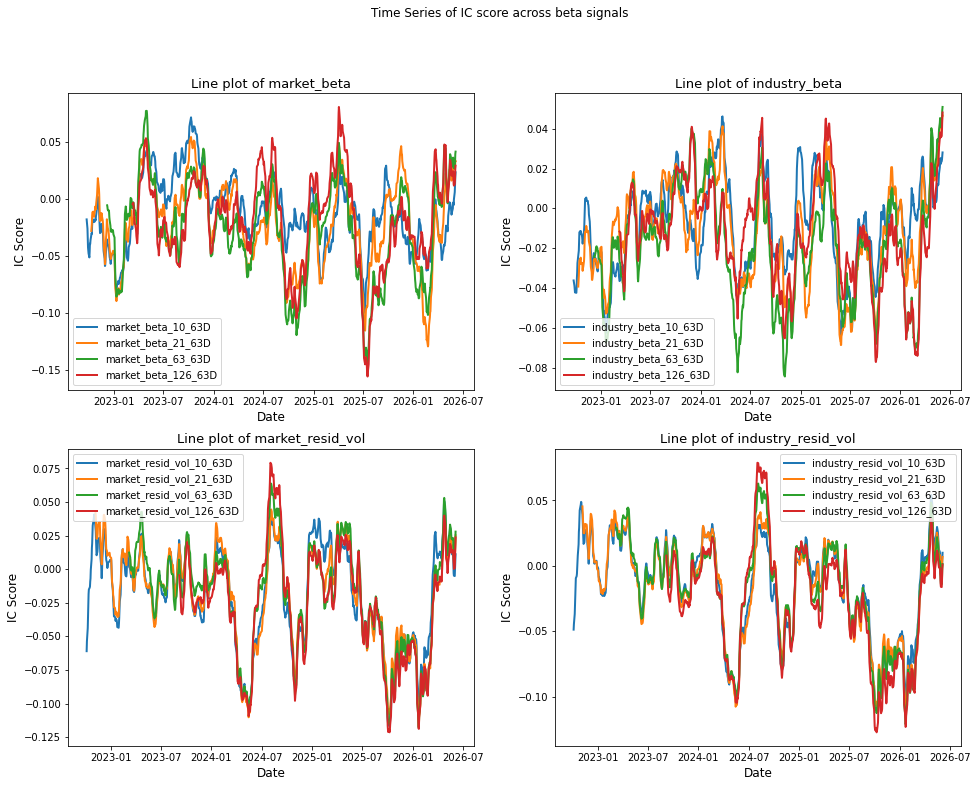

In [7]:
plot_ic_timeseries(beta_results_ic_dict, "beta")

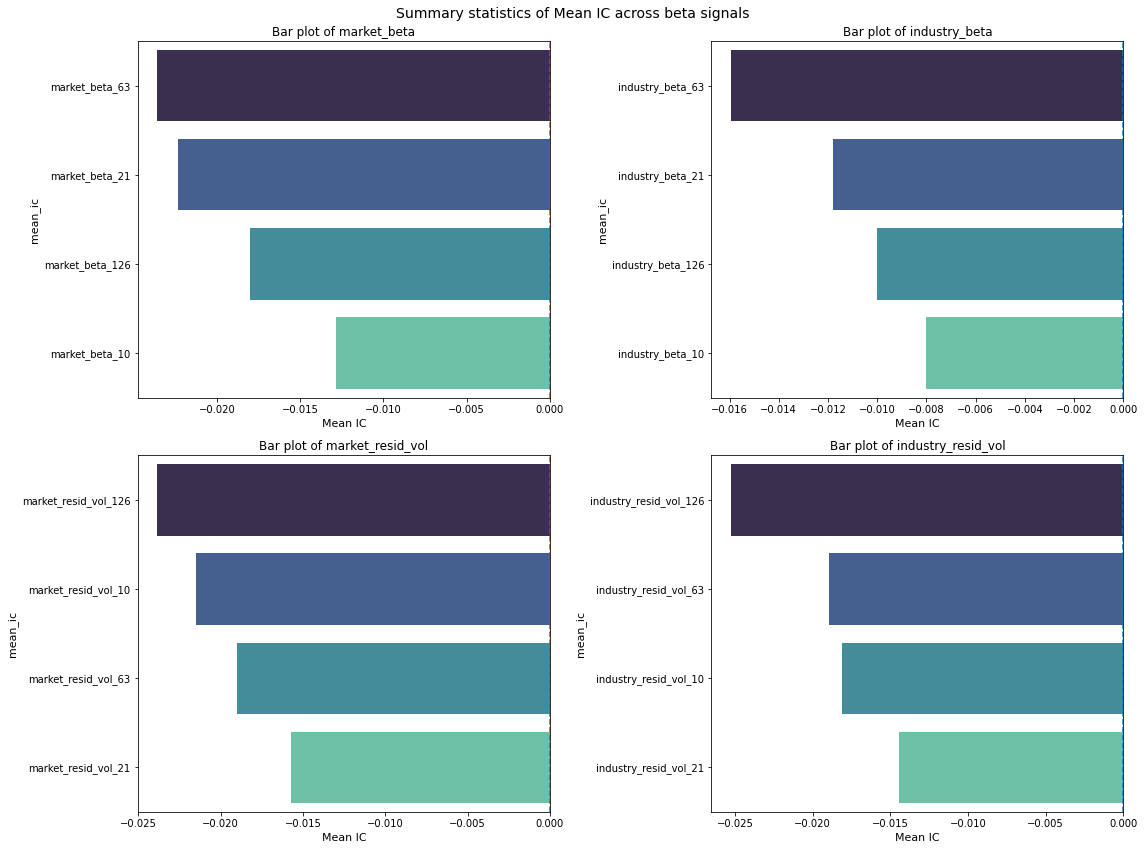

In [8]:
plot_ic_summary_bar(beta_results_ic_dict, beta_summary_ic_df, "beta", metric="mean_ic")

### Quintile Test

In [25]:
beta_results_quintile_dict, beta_summary_quintile_dict = results_quintile_dict["beta"], summary_quintile_dict["beta"]

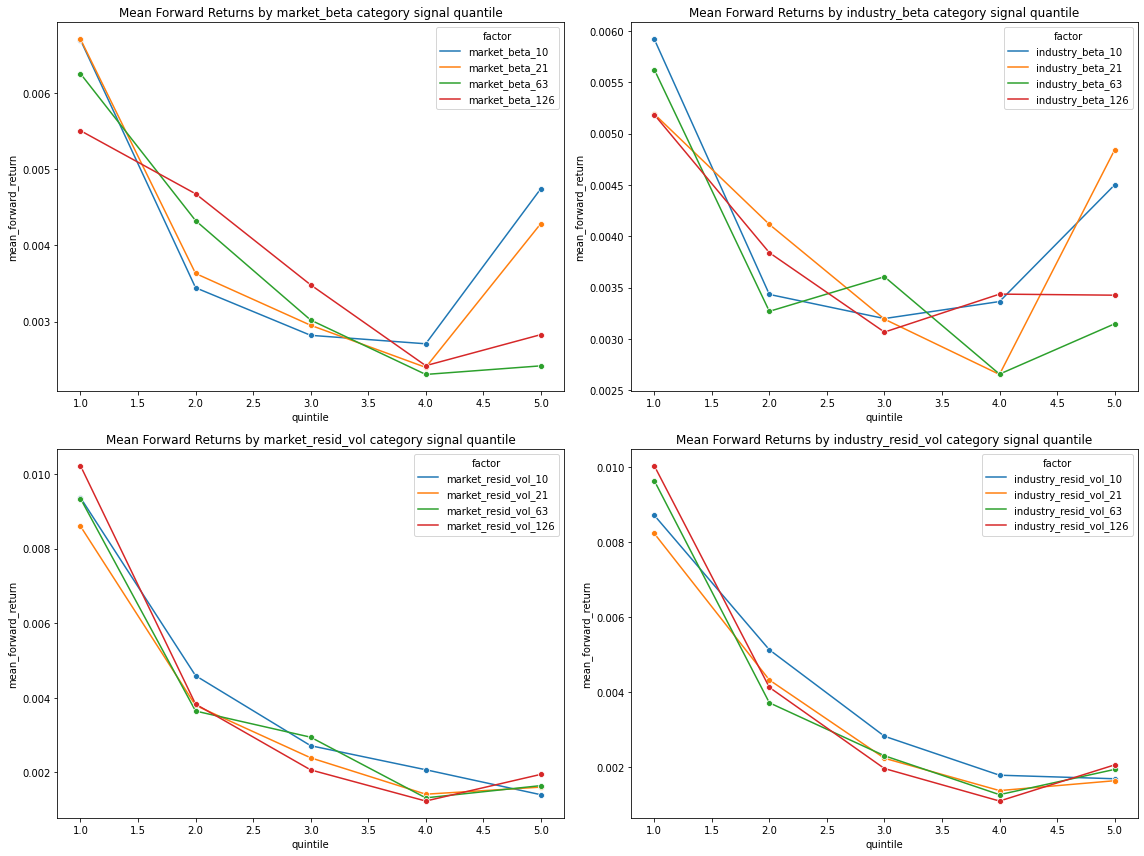

In [26]:
plot_quintiles(beta_results_quintile_dict, beta_summary_quintile_dict, "beta")

### Within family correlations

In [8]:
beta_factor_df = factors_df_dict["beta"]

market_beta_corr_df = beta_factor_df[["market_beta_10", "market_beta_21", "market_beta_63", "market_beta_126"]].corr("spearman")
industry_beta_corr_df = beta_factor_df[["industry_beta_10", "industry_beta_21", "industry_beta_63", "industry_beta_126"]].corr("spearman")
market_vol_corr_df = beta_factor_df[["market_resid_vol_10", "market_resid_vol_21", "market_resid_vol_63", "market_resid_vol_126"]].corr("spearman")
industry_vol_corr_df = beta_factor_df[["industry_resid_vol_10", "industry_resid_vol_21", "industry_resid_vol_63", "industry_resid_vol_126"]].corr("spearman")

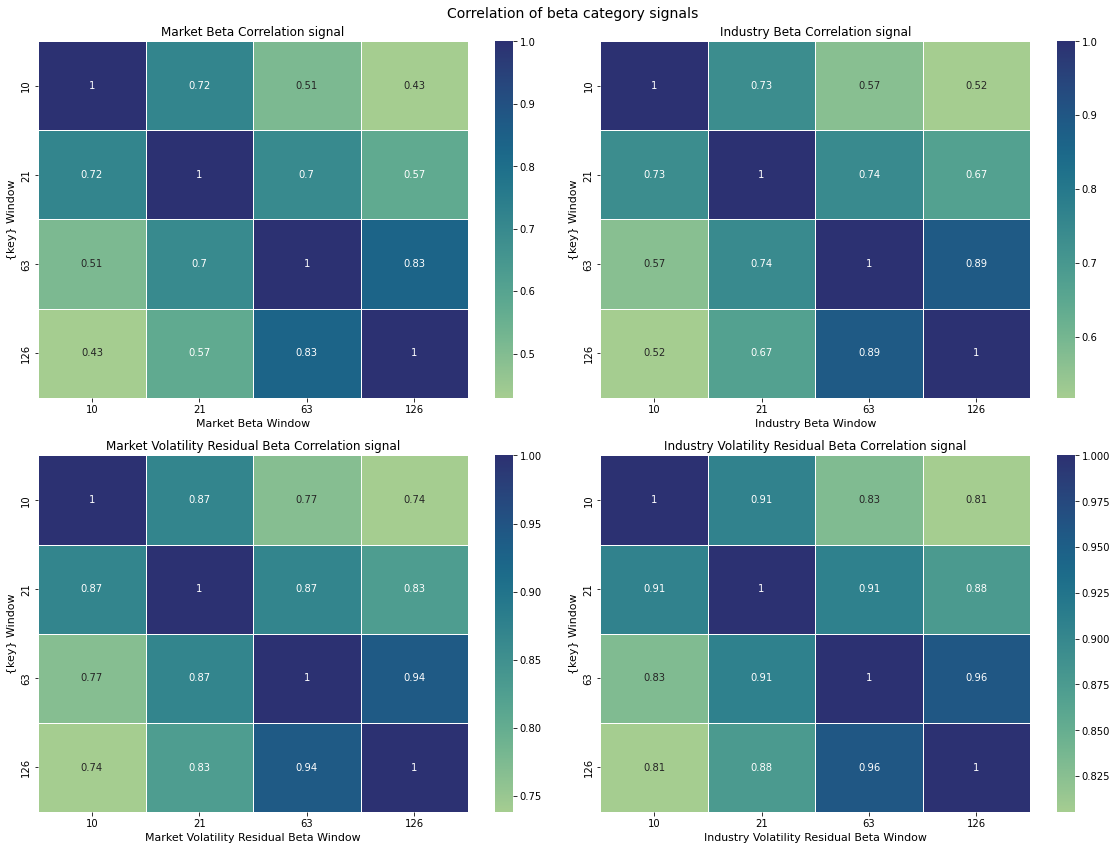

In [23]:
correlation_dfs_dict = {
    "Market Beta": market_beta_corr_df, 
    "Industry Beta": industry_beta_corr_df, 
    "Market Volatility Residual Beta": market_vol_corr_df, 
    "Industry Volatility Residual Beta": industry_vol_corr_df
}


fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Correlation of beta category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel("{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

### Summary

In [13]:
valid_beta_factors = ["industry_resid_vol_26", "market_resid_vol_126", "market_beta_63", "industry_beta_63"]

## Mean Volatility

### Information Coefficient

In [14]:
mv_results_ic_dict, mv_summary_ic_df = results_ic_dict["mean_volatility"], summary_ic_dict["mean_volatility"]

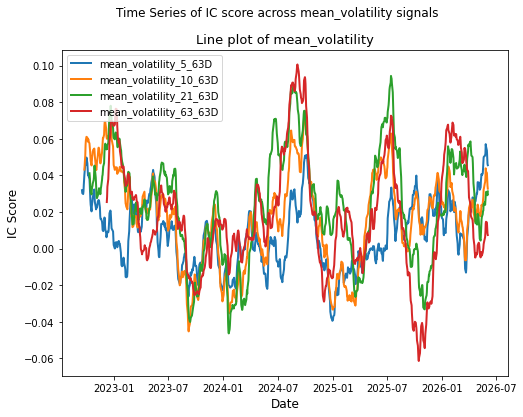

In [15]:
plot_ic_timeseries(mv_results_ic_dict, "mean_volatility")

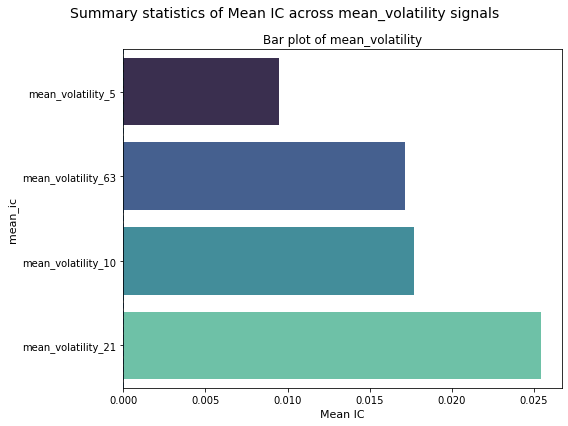

In [16]:
plot_ic_summary_bar(mv_results_ic_dict, mv_summary_ic_df, "mean_volatility", metric="mean_ic")

In [17]:
mv_results_quintile_dict, mv_summary_quintile_dict = results_quintile_dict["mean_volatility"], summary_quintile_dict["mean_volatility"]

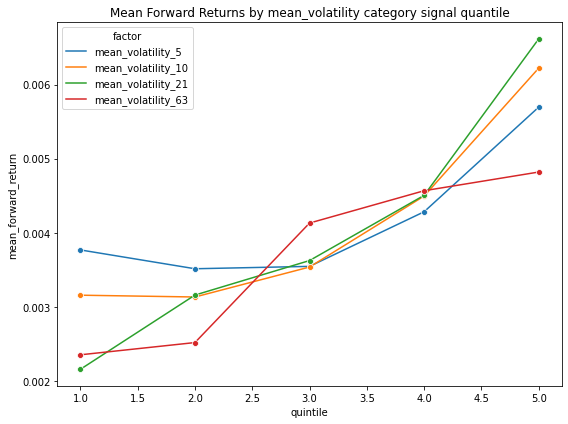

In [18]:
plot_quintiles(mv_results_quintile_dict, mv_summary_quintile_dict, "mean_volatility")

### Within family correlations

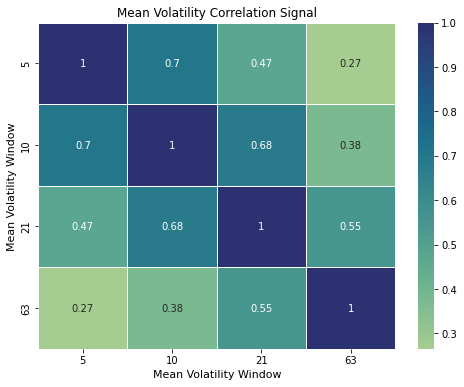

In [143]:
mv_df = factors_df_dict["mean_volatility"]
mv_corr_df = mv_df[mv_df.columns[2:]].corr("spearman")

mv_corr_df.index = [x.split('_')[-1] for x in mv_corr_df.index]
mv_corr_df.columns = [x.split('_')[-1] for x in mv_corr_df.columns]

plt.figure(figsize=(8, 6))
plt.title("Mean Volatility Correlation Signal", fontsize=12)
sns.heatmap(
    mv_corr_df, cmap="crest", annot=True, linewidths=1
)
plt.xlabel("Mean Volatility Window", fontsize=11)
plt.ylabel("Mean Volatility Window", fontsize=11)
plt.show()

## Microstructure

### Information Coefficient

In [15]:
microstructure_results_ic_dict, microstructure_summary_ic_df = results_ic_dict["microstructure"], summary_ic_dict["microstructure"]

In [16]:
microstructure_summary_ic_df

,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
mean_ic,0.005294,0.004635,0.004831,0.014862,0.012691,0.010887
std_ic,0.097905,0.097865,0.098002,0.117632,0.117947,0.116960
ic_ir,0.054070,0.047359,0.049293,0.126343,0.107600,0.093080
positive_ic_rate,0.520040,0.525077,0.526984,0.551655,0.553279,0.546610
n_periods,998.000000,977.000000,945.000000,997.000000,976.000000,944.000000


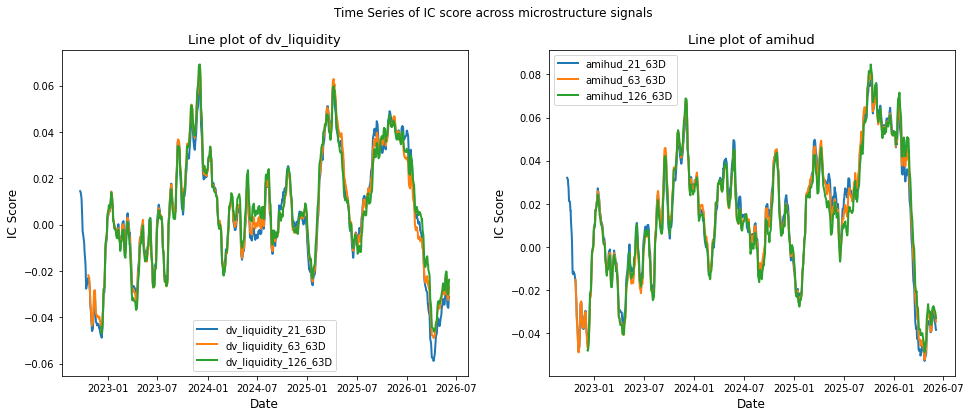

In [18]:
plot_ic_timeseries(microstructure_results_ic_dict, "microstructure")

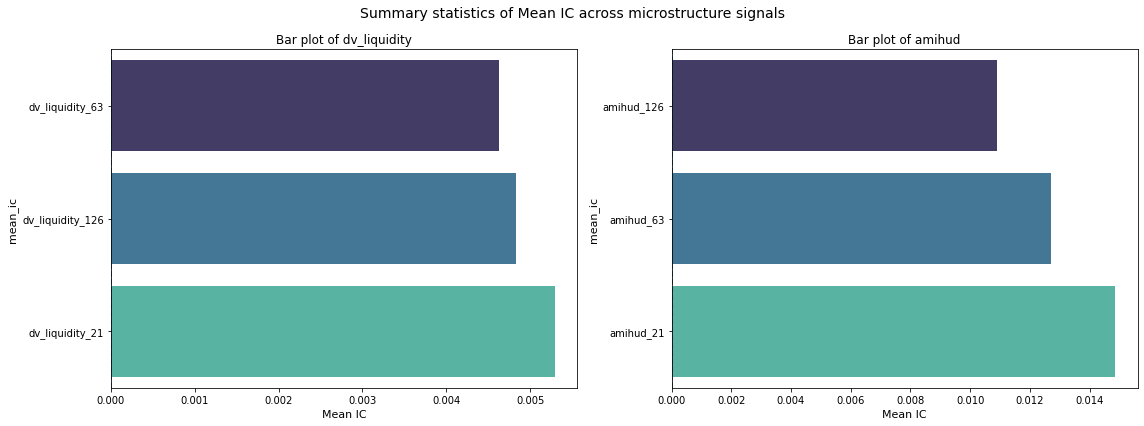

In [27]:
plot_ic_summary_bar(microstructure_results_ic_dict, microstructure_summary_ic_df, "microstructure", metric="mean_ic")

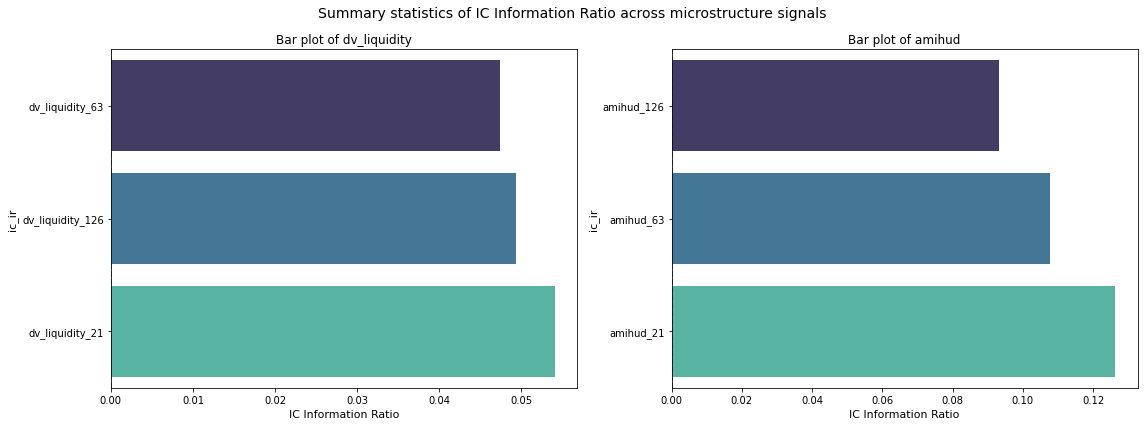

In [19]:
plot_ic_summary_bar(microstructure_results_ic_dict, microstructure_summary_ic_df, "microstructure", metric="ic_ir")

**Summary**: 

The rolling IC plots show both liquidity signals are regime-dependent, performing better across parts of 2023–2025 before weakening sharply in 2026. Amihud illiquidity is the stronger factor, achieving mean ICs of 0.0149, 0.0127, and 0.0109 for the 21-, 63-, and 126-day windows respectively, compared with only 0.0053, 0.0051, and 0.0046 for dollar-volume liquidity. Amihud 21 is the best-performing specification, with the highest ICIR (0.126) and a positive IC rate of approximately 55.2%, indicating the strongest and most consistent predictive power. Its disadvantage is that it is more volatile, with an IC standard deviation of around 0.118, compared with approximately 0.098 for dollar-volume liquidity. The strong overlap between the 21-, 63-, and 126-day variants suggests that the different lookback windows are capturing the same persistent liquidity effect rather than distinct sources of alpha, although shorter windows appear to contain more useful information. Overall, the results suggest that Amihud 21 should be preferred as the primary microstructure signal, while longer Amihud windows and dollar-volume liquidity may still provide diversification benefits when combined within a broader multi-factor framework.

### Quintile Test

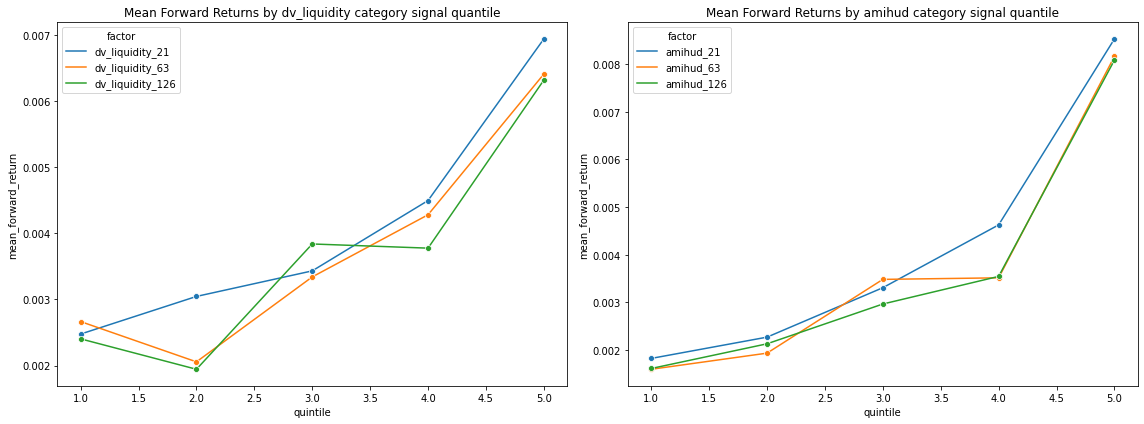

In [38]:
microstructure_results_quintile_dict, microstructure_summary_quintile_dict = results_quintile_dict["microstructure"], summary_quintile_dict["microstructure"]

microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10 = Quintile(returns_df, factors_df_dict["microstructure"], 10).run_data()

plot_quintiles(microstructure_results_quintile_dict, microstructure_summary_quintile_dict, "microstructure")

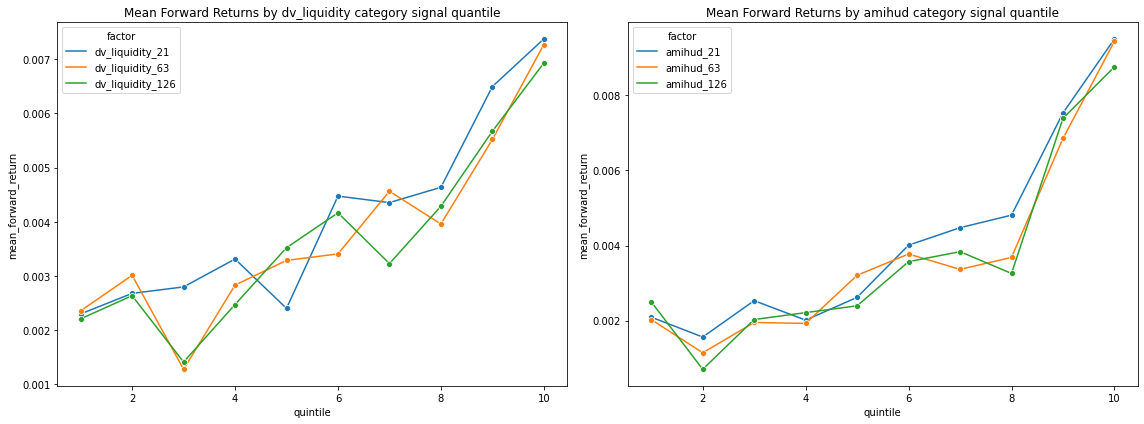

In [39]:
plot_quintiles(microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10, "microstructure")

In [30]:
microstructure_results_quintile_dict, microstructure_summary_quintile_dict = results_quintile_dict["microstructure"], summary_quintile_dict["microstructure"]

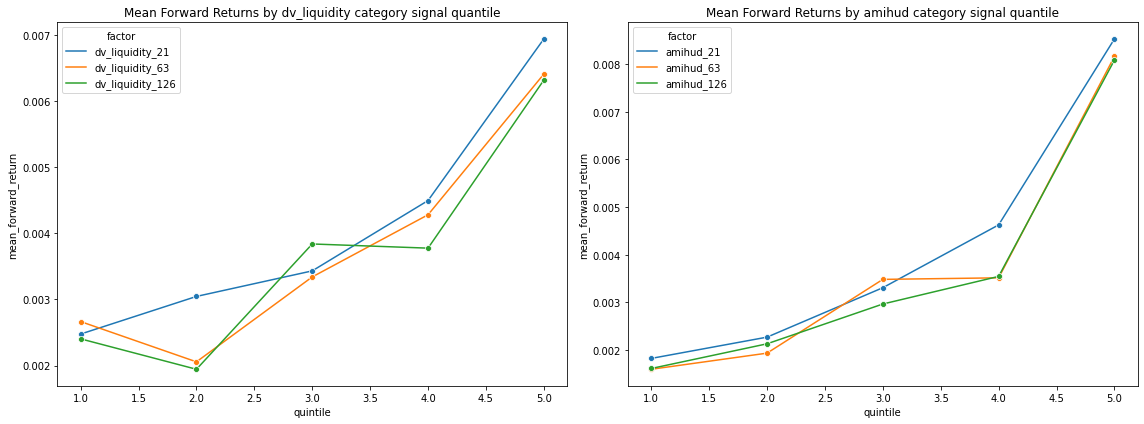

In [31]:
plot_quintiles(microstructure_results_quintile_dict, microstructure_summary_quintile_dict, "microstructure")

In [40]:
microstructure_df_factors

Index(['dv_liquidity_21', 'dv_liquidity_63', 'dv_liquidity_126', 'amihud_21',
       'amihud_63', 'amihud_126'],
      dtype='object')

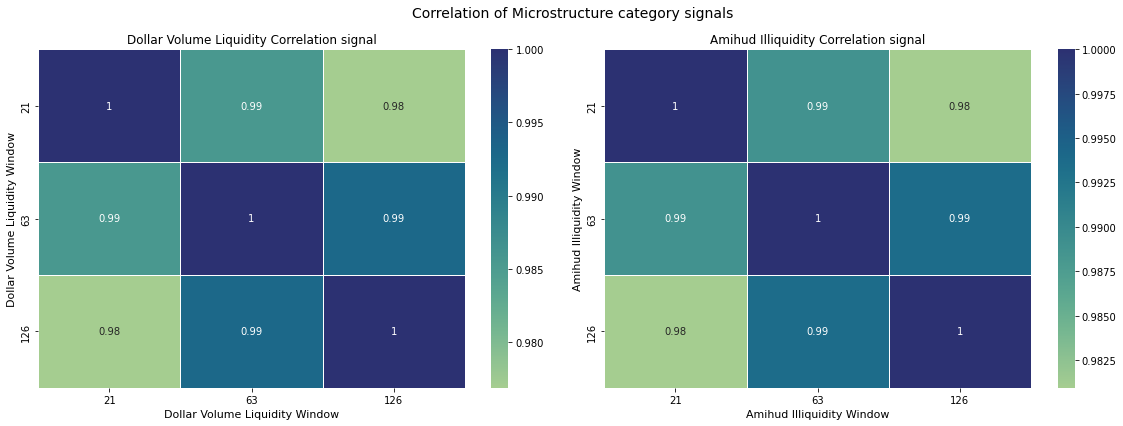

In [24]:
microstructure_df = factors_df_dict["microstructure"]

microstructure_df_factors = microstructure_df.columns[2:]
dv_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("dv_liquidity")]].corr("spearman")
amihud_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("amihud")]].corr("spearman")

correlation_dfs_dict = {
    "Dollar Volume Liquidity": dv_df_correlation,
    "Amihud Illiquidity": amihud_df_correlation
}

plot_correlation(correlation_dfs_dict, "Microstructure")

In [44]:
valid_factors = ["dv_liquidity_21", "amihud_21"]

microstructure_df_correlation = microstructure_df[valid_factors].corr("spearman")

microstructure_df_correlation

,dv_liquidity_21,amihud_21
dv_liquidity_21,1.000000,0.943146
amihud_21,0.943146,1.000000


**Summary**: As highlighted before we can see the the windows of both microstructure category signals are highly correlated. As a result we will choose our valid factors to be of window 21. We then tested correlation between two of the category signals and found that `dv_liquidity_21` is highly correlated with `amihud_21`. This means we will prefer `amihud_21` as a factor as explained earlier in the IC section.

## Momentum

### Information Coefficient

In [30]:
momentum_results_ic_dict, momentum_summary_ic_df = results_ic_dict["momentum"], summary_ic_dict["momentum"]

In [31]:
momentum_summary_ic_df

,momentum_63_21,momentum_126_21,momentum_252_21,id_63_21,id_126_21,id_252_21
mean_ic,0.014494,0.021786,0.044546,-0.000241,0.004651,0.017138
std_ic,0.165456,0.171714,0.173242,0.099071,0.105449,0.116036
ic_ir,0.087603,0.126876,0.257132,-0.002434,0.044105,0.147695
positive_ic_rate,0.531961,0.562791,0.637602,0.502709,0.512791,0.554496
n_periods,923.000000,860.000000,734.000000,923.000000,860.000000,734.000000


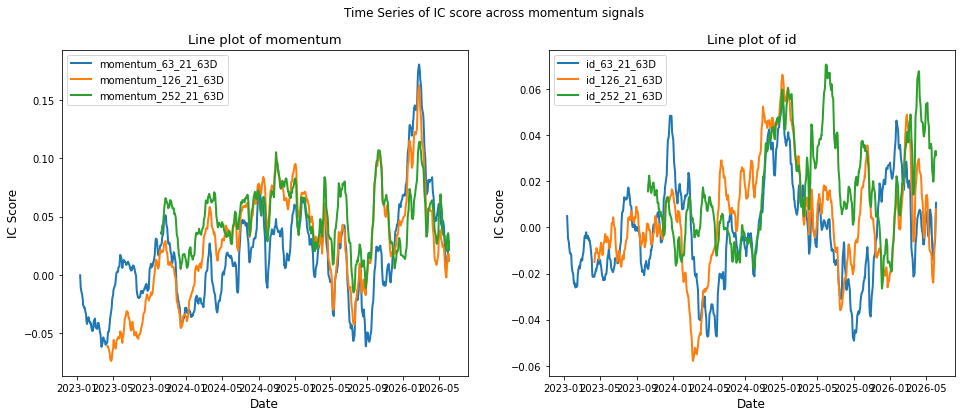

In [32]:
plot_ic_timeseries(momentum_results_ic_dict, "momentum")

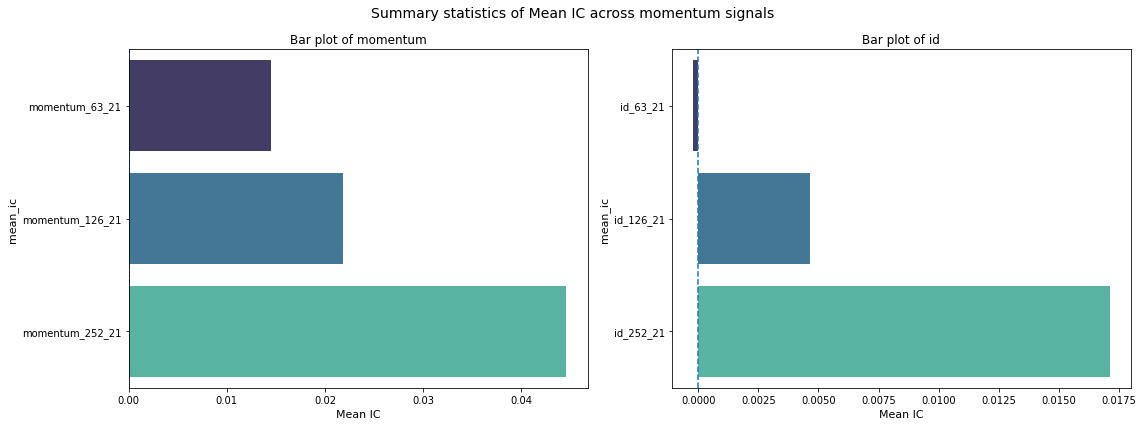

In [33]:
plot_ic_summary_bar(momentum_results_ic_dict, momentum_summary_ic_df, "momentum", metric="mean_ic")

In [34]:
momentum_results_quintile_dict, momentum_summary_quintile_dict = results_quintile_dict["momentum"], summary_quintile_dict["momentum"]

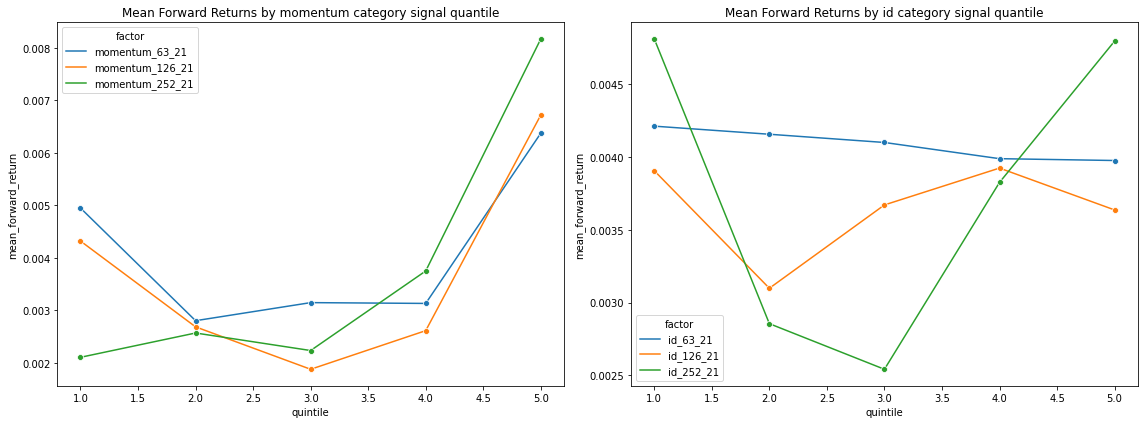

In [35]:
plot_quintiles(momentum_results_quintile_dict, momentum_summary_quintile_dict, "momentum")

In [36]:
momentum_quintile_10_dict, momentum_summary_quintile_10_df = Quintile(returns_df, factors_df_dict["momentum"], 10).run_data()

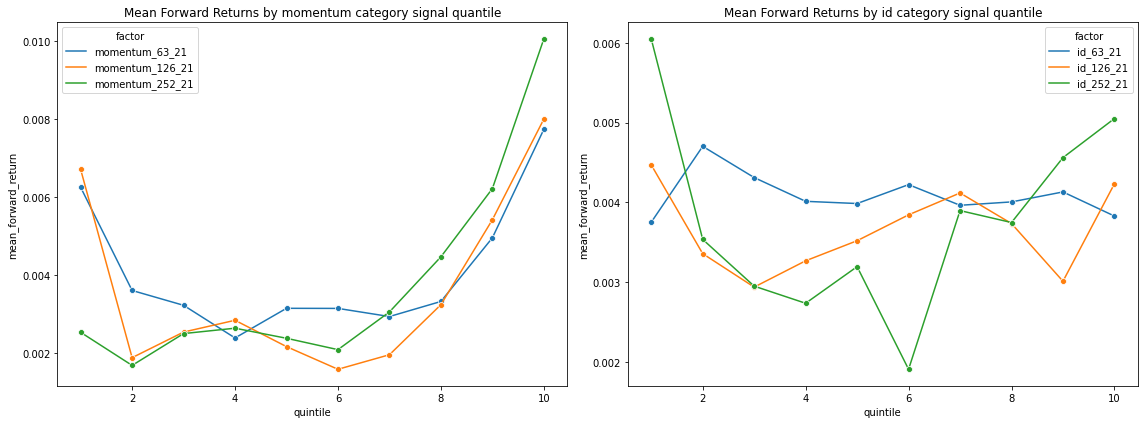

In [37]:
plot_quintiles(momentum_quintile_10_dict, momentum_summary_quintile_10_df, "momentum")

In [1]:
momentum_df = factors_df_dict["momentum"]
momentum_df_factors = momentum_df.columns[2:]
mom_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("momentum")]].corr("spearman")
id_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("id")]].corr("spearman")

NameError: name 'factors_df_dict' is not defined

In [42]:
correlation_dfs_dict = {
    "Momentum": mom_df_correlation, 
    "Information Discretenss": id_df_correlation
}

def plot_correlation(correlation_dfs_dict: dict, category_type: str): 
    n = len(correlation_dfs_dict.items())
    
    if (n == 2): 
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    fig.suptitle(f"Correlation of {category_type} category signals", fontsize=14)
    axs = axs.ravel()
    i = 0 
    for key, df in correlation_dfs_dict.items(): 
        df.index = [x.split('_')[-1] for x in df.index]
        df.columns = [x.split('_')[-1] for x in df.columns]
        sns.heatmap(
            df, ax=axs[i], cmap="crest", annot=True, linewidths=1
        )
        axs[i].set_title(f"{key} Correlation signal", fontsize=12)
        axs[i].set_xlabel(f"{key} Window", fontsize=11)
        axs[i].set_ylabel(f"{key} Window", fontsize=11)
        i += 1
    plt.tight_layout()
    plt.show()

In [49]:
valid_momentum_factors = ["momentum_252_12"]

## Momentum Liquidity

### Information Coefficient

In [10]:
ml_results_ic_dict, ml_summary_ic_df = results_ic_dict["momentum_liquidity"], summary_ic_dict["momentum_liquidity"]

In [11]:
ml_summary_ic_df

,momentum_liquidity_21,momentum_liquidity_63,momentum_liquidity_126
mean_ic,0.037321,0.037102,0.036599
std_ic,0.139096,0.141080,0.142334
ic_ir,0.268314,0.262987,0.257133
positive_ic_rate,0.611717,0.615804,0.613079
n_periods,734.000000,734.000000,734.000000


In [ ]:
### Information Coefficient

### Reversal

In [12]:
reversal_results_ic_dict, reversal_summary_ic_df = results_ic_dict["reversal"], summary_ic_dict["reversal"]

In [13]:
reversal_summary_ic_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


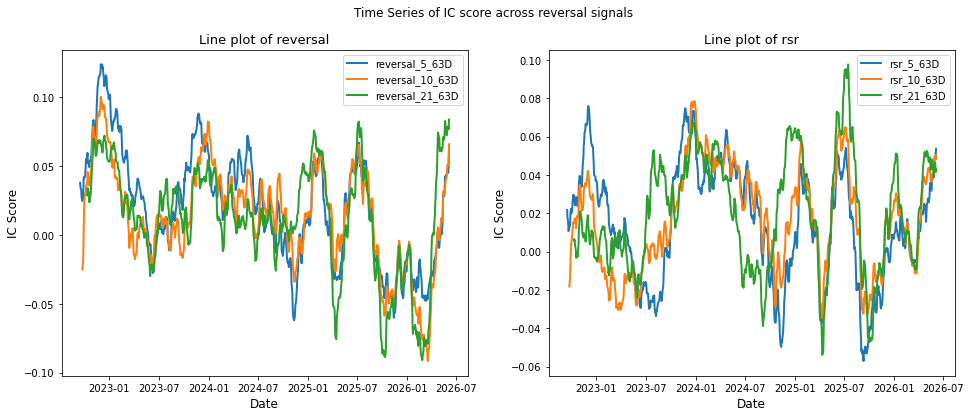

In [14]:
plot_ic_timeseries(reversal_results_ic_dict, "reversal")

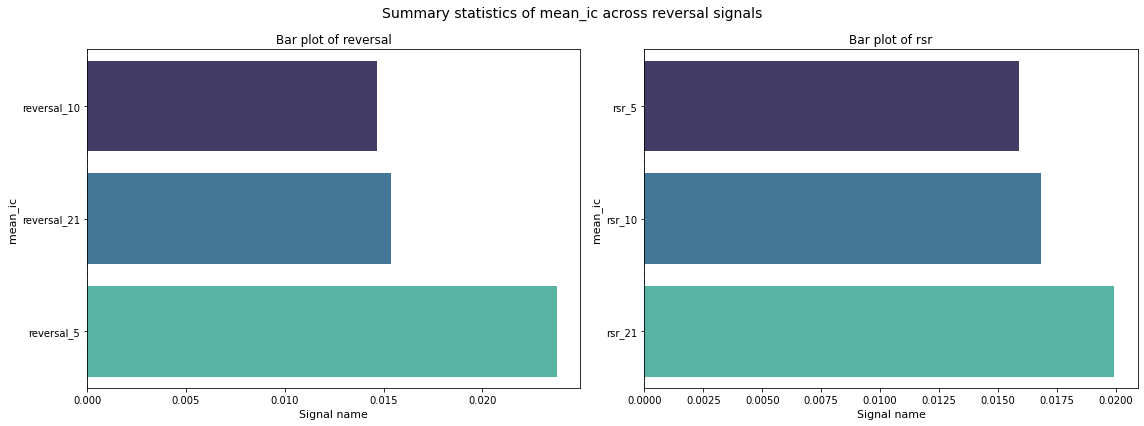

In [15]:
plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, "reversal", metric="mean_ic")

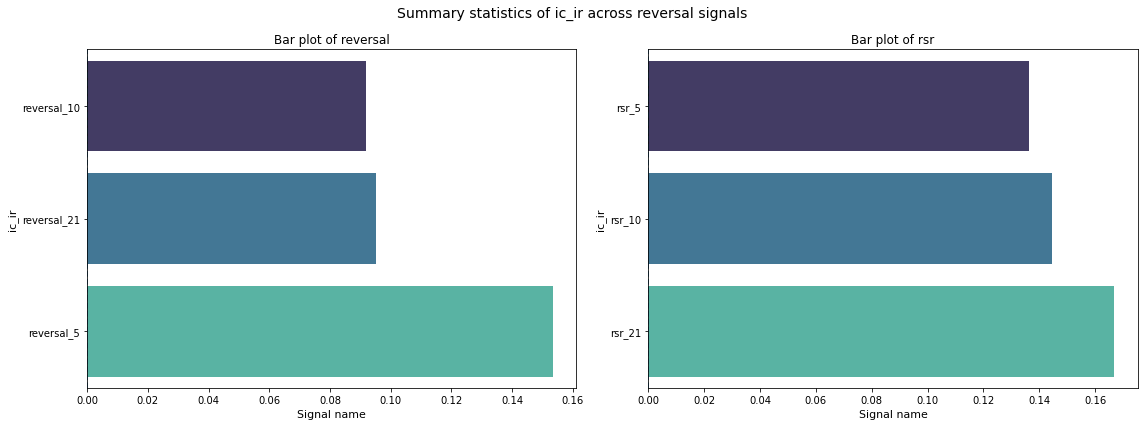

In [16]:
plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, "reversal", metric="ic_ir")

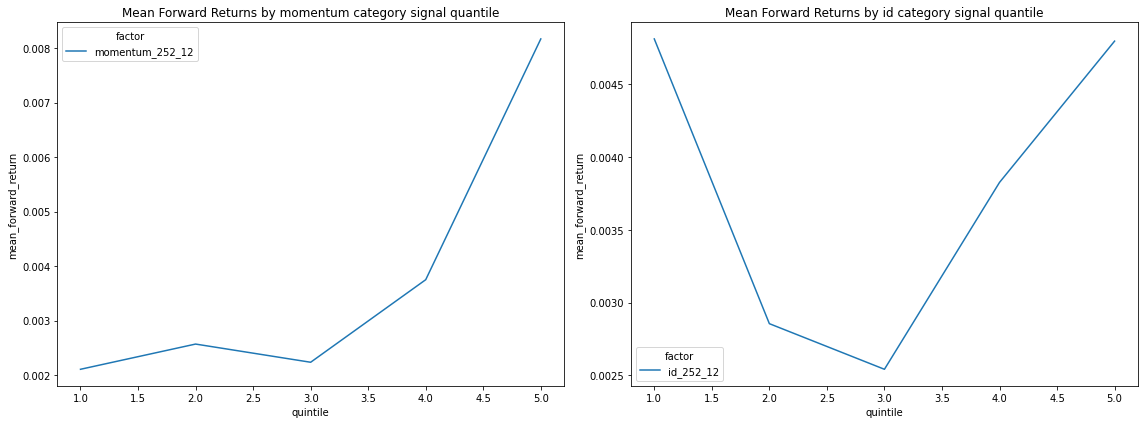

In [32]:
reversal_results_quintile_dict, reversal_summary_quintile_dict = results_quintile_dict["momentum"], summary_quintile_dict["momentum"]

plot_quintiles(reversal_results_quintile_dict, reversal_summary_quintile_dict, "momentum")

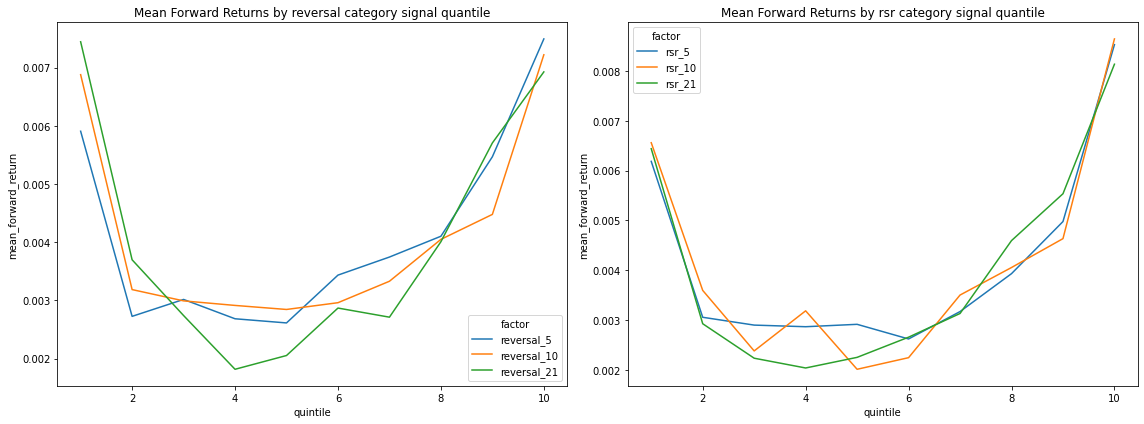

In [38]:
reversal_quintile_dict, reversal_summary_quintile_df = Quintile(returns_df, factors_df_dict["reversal"], 10).run_data()

plot_quintiles(reversal_quintile_dict, reversal_summary_quintile_df, "reversal")

In [ ]:
reversal_df = factors_df_dict["reversal"]
reversal_df_factors = reversal_df.columns[2:]
rev_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("reversal")]].corr("spearman")
rsr_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("rsr")]].corr("spearman")

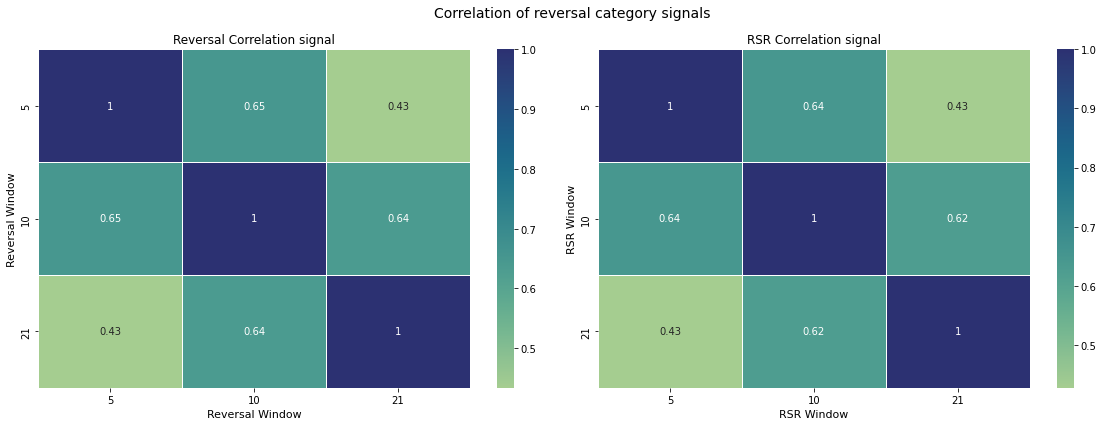

In [ ]:
correlation_dfs_dict = {
    "Reversal": rev_df_correlation, 
    "RSR": rsr_df_correlation
}


fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation of reversal category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel(f"{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

### PVO

In [39]:
pvo_results_ic_dict, pvo_summary_ic_df = results_ic_dict["pvo"], summary_ic_dict["pvo"]

In [42]:
pvo_summary_ic_df

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [44]:
plot_ic_timeseries(pvo_results_ic_dict, "pvo")

KeyError: 'pvo'

### Reversal Illiquidity

In [ ]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

In [31]:
reversal_ic_dict["reversal_10"]

{'reversal_5': {...},
 'reversal_10': {...},
 'reversal_21': {...},
 'rsr_5': {...},
 'rsr_10': {...},
 'rsr_21': {...}}

<AxesSubplot:>

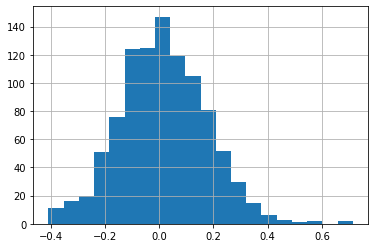

In [16]:
reversal_ic_dict["reversal_21"].hist(bins=20)

In [18]:
IC(returns_df, factors_df_dict["momentum_liquidity"]).run_data()

({'momentum_liquidity_21':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_21  future_return_5d  0.107145
  1   2023-07-14  momentum_liquidity_21  future_return_5d  0.002506
  2   2023-07-17  momentum_liquidity_21  future_return_5d -0.016175
  3   2023-07-18  momentum_liquidity_21  future_return_5d  0.011867
  4   2023-07-19  momentum_liquidity_21  future_return_5d  0.061042
  ..         ...                    ...               ...       ...
  729 2026-05-29  momentum_liquidity_21  future_return_5d -0.059243
  730 2026-06-01  momentum_liquidity_21  future_return_5d -0.145856
  731 2026-06-02  momentum_liquidity_21  future_return_5d -0.261944
  732 2026-06-03  momentum_liquidity_21  future_return_5d -0.287476
  733 2026-06-04  momentum_liquidity_21  future_return_5d -0.228393
  
  [734 rows x 4 columns],
  'momentum_liquidity_63':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_

In [8]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [9]:
IC(returns_df, factors_df_dict["reversal"]).run_data()

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


In [11]:
IC(returns_df, factors_df_dict["reversal_illiquidity"]).run_data()

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)","reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)","reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
mean_ic,0.000906,0.002136,0.004395,-0.005545,-0.003548,-0.000557,-0.002796,-0.003191,-0.001153
std_ic,0.137560,0.138776,0.138489,0.143973,0.145102,0.143113,0.142457,0.145326,0.144678
ic_ir,0.006588,0.015390,0.031733,-0.038513,-0.024449,-0.003893,-0.019629,-0.021957,-0.007972
positive_ic_rate,0.491474,0.494877,0.501059,0.484453,0.483607,0.495763,0.489858,0.495902,0.502119
n_periods,997.000000,976.000000,944.000000,997.000000,976.000000,944.000000,986.000000,976.000000,944.000000
